In [1]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set(style='whitegrid')

In [5]:
# Locate and load all v1 vs v2 CSVs generated by testing_heuristic_v3_v1_vs_v2.py\n
data_dir = os.path.join('..', 'data')
pattern = os.path.join(data_dir, 'tfm_doubles_v1_vs_v2_*.csv')
csv_files = sorted(glob.glob(pattern))

if not csv_files:
    raise FileNotFoundError(f'No CSV files found matching {pattern!r}. Run testing_heuristic_v3_v1_vs_v2.py first.')

print('Found CSV files:')
for f in csv_files:
    print(' -', os.path.basename(f))

df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
print(f"\nTotal battles loaded: {len(df):,}")
display(df.head())

Found CSV files:
 - tfm_doubles_v1_vs_v2_fc58.csv

Total battles loaded: 10,000


,battle_id,winner,turns,player_heuristic,opponent_heuristic
0,battle-gen9randomdoublesbattle-60159,v2,10,v1,v2
1,battle-gen9randomdoublesbattle-60160,v2,17,v1,v2
2,battle-gen9randomdoublesbattle-60161,v1,21,v1,v2
3,battle-gen9randomdoublesbattle-60162,v2,15,v1,v2
4,battle-gen9randomdoublesbattle-60163,v1,26,v1,v2


In [6]:
# Basic overall results: win rates and mean turns\n
summary = (
    df.groupby('winner')
      .agg(
          battles=('battle_id', 'count'),
          mean_turns=('turns', 'mean'),
          sd_turns=('turns', 'std'),
      )
      .reset_index()
)

total_battles = summary['battles'].sum()
summary['win_rate_%'] = 100 * summary['battles'] / total_battles

print('--- Overall outcomes ---')
display(summary)

--- Overall outcomes ---


,winner,battles,mean_turns,sd_turns,win_rate_%
0,v1,4968,17.492754,6.038694,49.68
1,v2,5032,17.467210,6.095421,50.32


In [7]:
# Side-aware analysis: treat v1/v2 separately depending on whether they were
# the 'player' or the 'opponent'.
def compute_heuristic_win_stats(df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for heuristic in ['v1', 'v2']:
        # As player\n
        as_player = df[df['player_heuristic'] == heuristic]
        wins_p = (as_player['winner'] == heuristic).sum()
        battles_p = len(as_player)
        # As opponent\n
        as_opp = df[df['opponent_heuristic'] == heuristic]
        wins_o = (as_opp['winner'] == heuristic).sum()
        battles_o = len(as_opp)

        total_wins = wins_p + wins_o
        total_battles = battles_p + battles_o
        win_rate = 100 * total_wins / total_battles if total_battles else np.nan

        records.append({
            'heuristic': heuristic,
            'battles_total': total_battles,
            'wins_total': total_wins,
            'win_rate_%': win_rate,
            'battles_as_player': battles_p,
            'wins_as_player': wins_p,
            'battles_as_opponent': battles_o,
            'wins_as_opponent': wins_o,
        })

    return pd.DataFrame.from_records(records)

heuristic_stats = compute_heuristic_win_stats(df)
print('\n--- Heuristic-level results (v1 vs v2) ---')
display(heuristic_stats)


--- Heuristic-level results (v1 vs v2) ---


,heuristic,battles_total,wins_total,win_rate_%,battles_as_player,wins_as_player,battles_as_opponent,wins_as_opponent
0,v1,10000,4968,49.68,5000,2426,5000,2542
1,v2,10000,5032,50.32,5000,2458,5000,2574


/tmp/ipykernel_21937/3769179974.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=heuristic_stats, x='heuristic', y='win_rate_%', palette='viridis')


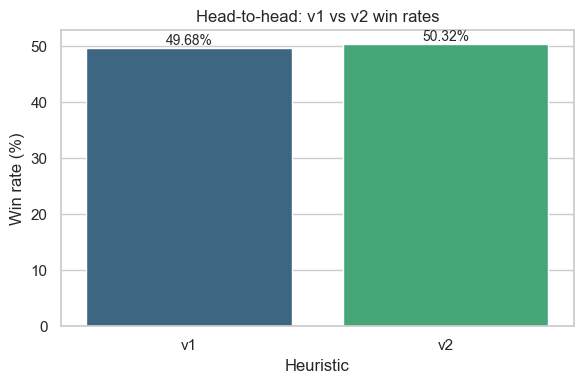

In [8]:
# Simple barplot of win rate per heuristic\n
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=heuristic_stats, x='heuristic', y='win_rate_%', palette='viridis')
ax.set_ylabel('Win rate (%)')
ax.set_xlabel('Heuristic')
ax.set_title('Head-to-head: v1 vs v2 win rates')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()